In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression #sistemi eğitmek için
from sklearn.metrics import mean_squared_error, r2_score #sistemin başarısını ölçmek için

In [2]:
train_df = pd.read_csv("student_loan_train.xls")

In [3]:
train_df

,year,debt
0,4,347.1
1,5,392.8
2,6,478.8
3,7,541.3
4,8,633.3
5,9,714.4
6,10,803.5
7,11,866.3
8,12,959.9
9,13,1071.0


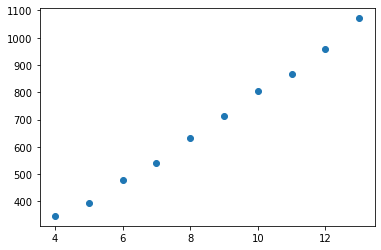

In [4]:
plt.scatter(train_df["year"], train_df["debt"])
plt.show()

In [5]:
x_train = train_df.drop("debt", axis = 1)
y_train = train_df["debt"]

In [6]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [7]:
w1 = model.coef_[0]
w1

80.54545454545452

In [8]:
w0 = model.intercept_
w0

-3.7963636363634805

In [9]:
X = np.linspace(1, 17, 100) #linscape 

In [10]:
Y = w1*X + w0

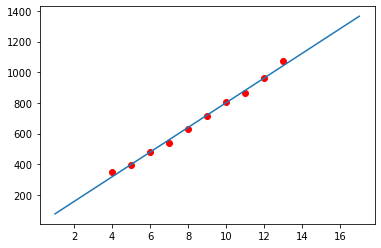

In [11]:
plt.scatter(train_df["year"], train_df["debt"], color = "r")
plt.plot(X, Y)
plt.show()

In [12]:
test_df = pd.read_csv("test.xls")
test_df

,year,debt
0,14,1155.83
1,15,1271.84
2,16,1358.13


In [13]:
x_test = test_df.drop("debt", axis = 1)
y_test = test_df["debt"]

In [14]:
y_pred = model.predict(x_test)
y_pred

array([1123.84      , 1204.38545455, 1284.93090909])

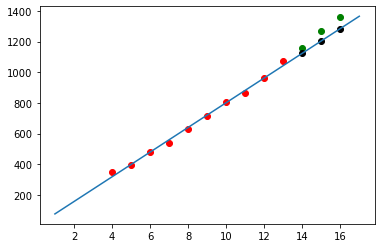

In [15]:
plt.scatter(train_df["year"], train_df["debt"], color = "r")
plt.scatter(test_df["year"], test_df["debt"], color = "g")
plt.scatter(test_df["year"],y_pred, color = "k")
plt.plot(X, Y)
plt.show()

In [16]:
mse = mean_squared_error(y_pred, y_test)
mse

3643.860904132273

In [17]:
r2 = r2_score(y_test, y_pred)
r2

0.46959446896546153

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [19]:
df = pd.read_excel("GrupC.xlsx")
df

,Bakim_ID,Bakim_Onceligi,Vardiya,Tesis_Bolgesi,Makine_Saglik_Durumu,Makine_Yasi,Calisma_Saati,Titreşim_Seviyesi,Ariza_Sayisi,Duruş_Suresi_Saat,Ortam_Sicakligi,Toplam_Bakim_Maliyeti
0,BKM1001,Dusuk,Gece,Guney,Kusursuz,1.0,1960.0,1.16,3.0,10.4,41.8,15767.85
1,BKM1002,Orta,Gece,Dogu,Kusursuz,7.0,924.0,1.40,1.0,8.1,30.2,14756.24
2,BKM1003,Kritik,Gece,Batı,Yıpranmış,5.0,2113.0,1.69,4.0,9.2,25.7,24976.29
3,BKM1004,Kritik,Gece,Merkez,Zayıf,12.0,2898.0,2.20,0.0,7.4,22.0,25770.41
4,BKM1005,Orta,Hafta Sonu,Dogu,Kritik,10.0,1925.0,1.26,3.0,3.4,28.1,15910.66
...,...,...,...,...,...,...,...,...,...,...,...,...
495,BKM1496,Dusuk,Gunduz,Kuzey,Yıpranmış,1.0,1354.0,2.34,5.0,19.9,43.2,23918.19
496,BKM1497,Orta,Hafta Sonu,Kuzey,Yıpranmış,6.0,1868.0,3.57,4.0,3.6,33.1,24398.57
497,BKM1498,Yuksek,Hafta Sonu,Kuzey,Zayıf,12.0,1797.0,1.55,3.0,9.8,29.2,23983.28
498,BKM1499,Dusuk,Hafta Sonu,Dogu,Kritik,4.0,875.0,0.88,2.0,8.5,38.7,18017.30


In [20]:
df = df.drop("Bakim_ID", axis = 1)
df

,Bakim_Onceligi,Vardiya,Tesis_Bolgesi,Makine_Saglik_Durumu,Makine_Yasi,Calisma_Saati,Titreşim_Seviyesi,Ariza_Sayisi,Duruş_Suresi_Saat,Ortam_Sicakligi,Toplam_Bakim_Maliyeti
0,Dusuk,Gece,Guney,Kusursuz,1.0,1960.0,1.16,3.0,10.4,41.8,15767.85
1,Orta,Gece,Dogu,Kusursuz,7.0,924.0,1.40,1.0,8.1,30.2,14756.24
2,Kritik,Gece,Batı,Yıpranmış,5.0,2113.0,1.69,4.0,9.2,25.7,24976.29
3,Kritik,Gece,Merkez,Zayıf,12.0,2898.0,2.20,0.0,7.4,22.0,25770.41
4,Orta,Hafta Sonu,Dogu,Kritik,10.0,1925.0,1.26,3.0,3.4,28.1,15910.66
...,...,...,...,...,...,...,...,...,...,...,...
495,Dusuk,Gunduz,Kuzey,Yıpranmış,1.0,1354.0,2.34,5.0,19.9,43.2,23918.19
496,Orta,Hafta Sonu,Kuzey,Yıpranmış,6.0,1868.0,3.57,4.0,3.6,33.1,24398.57
497,Yuksek,Hafta Sonu,Kuzey,Zayıf,12.0,1797.0,1.55,3.0,9.8,29.2,23983.28
498,Dusuk,Hafta Sonu,Dogu,Kritik,4.0,875.0,0.88,2.0,8.5,38.7,18017.30


In [21]:
df["Bakim_Onceligi"].value_counts()

Orta      182
Yuksek    127
Dusuk     114
Kritik     67
?          10
Name: Bakim_Onceligi, dtype: int64

In [22]:
df["Bakim_Onceligi"] = df["Bakim_Onceligi"].replace("?", pd.NA)
df["Bakim_Onceligi"].value_counts()

Orta      182
Yuksek    127
Dusuk     114
Kritik     67
Name: Bakim_Onceligi, dtype: int64

In [23]:
df["Vardiya"].value_counts()

Gunduz        274
Gece          155
Hafta Sonu     60
Name: Vardiya, dtype: int64

In [24]:
df["Tesis_Bolgesi"].value_counts()

Merkez    133
Kuzey     100
Guney      97
Dogu       80
Bati       70
Batı        7
Name: Tesis_Bolgesi, dtype: int64

In [25]:
df["Tesis_Bolgesi"] = df["Tesis_Bolgesi"].replace("Batı", "Bati")

In [26]:
df["Tesis_Bolgesi"].value_counts()

Merkez    133
Kuzey     100
Guney      97
Dogu       80
Bati       77
Name: Tesis_Bolgesi, dtype: int64

In [27]:
df["Makine_Saglik_Durumu"].value_counts()

Kritik       137
Zayıf        134
Yıpranmış     90
Kusursuz      61
İyi           42
Name: Makine_Saglik_Durumu, dtype: int64

In [28]:
df.isnull().sum()

Bakim_Onceligi           10
Vardiya                  11
Tesis_Bolgesi            13
Makine_Saglik_Durumu     36
Makine_Yasi              14
Calisma_Saati            18
Titreşim_Seviyesi        16
Ariza_Sayisi             15
Duruş_Suresi_Saat        14
Ortam_Sicakligi          14
Toplam_Bakim_Maliyeti     0
dtype: int64

In [29]:
x = df.groupby("Tesis_Bolgesi")["Bakim_Onceligi"].transform(lambda x: x.mode()[0])
df["Bakim_Onceligi"] = df["Bakim_Onceligi"].fillna(x)
df["Bakim_Onceligi"].isnull().sum()

0

In [30]:
df = df.dropna()

In [31]:
x = df.groupby("Tesis_Bolgesi")["Vardiya"].transform(lambda x: x.mode()[0])
df["Vardiya"] = df["Vardiya"].fillna(x)
df["Vardiya"].isnull().sum()

C:\Users\IGU-OGRENCI\AppData\Local\Temp\ipykernel_7352\695669936.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Vardiya"] = df["Vardiya"].fillna(x)


0

In [32]:
x = df.groupby("Vardiya")["Tesis_Bolgesi"].transform(lambda x: x.mode()[0])
df["Tesis_Bolgesi"] = df["Tesis_Bolgesi"].fillna(x)
df["Tesis_Bolgesi"].isnull().sum()

C:\Users\IGU-OGRENCI\AppData\Local\Temp\ipykernel_7352\21896472.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Tesis_Bolgesi"] = df["Tesis_Bolgesi"].fillna(x)


0

In [33]:
x = df.groupby("Vardiya")["Makine_Saglik_Durumu"].transform(lambda x: x.mode()[0])
df["Makine_Saglik_Durumu"] = df["Makine_Saglik_Durumu"].fillna(x)
df["Makine_Saglik_Durumu"].isnull().sum()

C:\Users\IGU-OGRENCI\AppData\Local\Temp\ipykernel_7352\3974468803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Makine_Saglik_Durumu"] = df["Makine_Saglik_Durumu"].fillna(x)


0

In [34]:
x = df.groupby("Vardiya")["Makine_Yasi"].transform("median")
df["Makine_Yasi"] = df["Makine_Yasi"].fillna(x)
df["Makine_Yasi"].isnull().sum()

C:\Users\IGU-OGRENCI\AppData\Local\Temp\ipykernel_7352\1955888425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Makine_Yasi"] = df["Makine_Yasi"].fillna(x)


0

In [35]:
x = df.groupby("Vardiya")["Calisma_Saati"].transform("mean")
df["Calisma_Saati"] = df["Calisma_Saati"].fillna(x)
df["Calisma_Saati"].isnull().sum()

C:\Users\IGU-OGRENCI\AppData\Local\Temp\ipykernel_7352\41965646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Calisma_Saati"] = df["Calisma_Saati"].fillna(x)


0

In [36]:
x = df.groupby("Vardiya")["Titreşim_Seviyesi"].transform("mean")
df["Titreşim_Seviyesi"] = df["Titreşim_Seviyesi"].fillna(x)
df["Titreşim_Seviyesi"].isnull().sum()

C:\Users\IGU-OGRENCI\AppData\Local\Temp\ipykernel_7352\2518401504.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Titreşim_Seviyesi"] = df["Titreşim_Seviyesi"].fillna(x)


0

In [37]:
x = df.groupby("Vardiya")["Ariza_Sayisi"].transform("mean")
df["Ariza_Sayisi"] = df["Ariza_Sayisi"].fillna(x)
df["Ariza_Sayisi"].isnull().sum()

C:\Users\IGU-OGRENCI\AppData\Local\Temp\ipykernel_7352\873098681.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ariza_Sayisi"] = df["Ariza_Sayisi"].fillna(x)


0

In [38]:
x = df.groupby("Vardiya")["Duruş_Suresi_Saat"].transform("mean")
df["Duruş_Suresi_Saat"] = df["Duruş_Suresi_Saat"].fillna(x)
df["Duruş_Suresi_Saat"].isnull().sum()

C:\Users\IGU-OGRENCI\AppData\Local\Temp\ipykernel_7352\596368054.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Duruş_Suresi_Saat"] = df["Duruş_Suresi_Saat"].fillna(x)


0

In [39]:
df.isnull().sum()

Bakim_Onceligi           0
Vardiya                  0
Tesis_Bolgesi            0
Makine_Saglik_Durumu     0
Makine_Yasi              0
Calisma_Saati            0
Titreşim_Seviyesi        0
Ariza_Sayisi             0
Duruş_Suresi_Saat        0
Ortam_Sicakligi          0
Toplam_Bakim_Maliyeti    0
dtype: int64

In [40]:
df = pd.get_dummies(df, columns=["Vardiya","Tesis_Bolgesi"], drop_first = True, dtype=int)
df

,Bakim_Onceligi,Makine_Saglik_Durumu,Makine_Yasi,Calisma_Saati,Titreşim_Seviyesi,Ariza_Sayisi,Duruş_Suresi_Saat,Ortam_Sicakligi,Toplam_Bakim_Maliyeti,Vardiya_Gunduz,Vardiya_Hafta Sonu,Tesis_Bolgesi_Dogu,Tesis_Bolgesi_Guney,Tesis_Bolgesi_Kuzey,Tesis_Bolgesi_Merkez
0,Dusuk,Kusursuz,1.0,1960.0,1.16,3.0,10.4,41.8,15767.85,0,0,0,1,0,0
1,Orta,Kusursuz,7.0,924.0,1.40,1.0,8.1,30.2,14756.24,0,0,1,0,0,0
2,Kritik,Yıpranmış,5.0,2113.0,1.69,4.0,9.2,25.7,24976.29,0,0,0,0,0,0
3,Kritik,Zayıf,12.0,2898.0,2.20,0.0,7.4,22.0,25770.41,0,0,0,0,0,1
4,Orta,Kritik,10.0,1925.0,1.26,3.0,3.4,28.1,15910.66,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,Dusuk,Zayıf,3.0,2542.0,2.46,4.0,4.8,31.1,19321.94,0,0,0,0,0,1
495,Dusuk,Yıpranmış,1.0,1354.0,2.34,5.0,19.9,43.2,23918.19,1,0,0,0,1,0
496,Orta,Yıpranmış,6.0,1868.0,3.57,4.0,3.6,33.1,24398.57,0,1,0,0,1,0
497,Yuksek,Zayıf,12.0,1797.0,1.55,3.0,9.8,29.2,23983.28,0,1,0,0,1,0


In [41]:
df["Bakim_Onceligi"].value_counts()

Orta      144
Dusuk      89
Yuksek     85
Kritik     50
Name: Bakim_Onceligi, dtype: int64

In [42]:
df["Bakim_Onceligi"] = df["Bakim_Onceligi"].map({
    "Kritik":0,
    "Dusuk":1,
    "Orta":2,
    "Yuksek":3
})
df["Makine_Saglik_Durumu"] = df["Makine_Saglik_Durumu"].map({
    "Kritik":0,
    "Yıpranmış":1,
    "Zayıf":2,
    "İyi":3,
    "Kusursuz":4
})
df

,Bakim_Onceligi,Makine_Saglik_Durumu,Makine_Yasi,Calisma_Saati,Titreşim_Seviyesi,Ariza_Sayisi,Duruş_Suresi_Saat,Ortam_Sicakligi,Toplam_Bakim_Maliyeti,Vardiya_Gunduz,Vardiya_Hafta Sonu,Tesis_Bolgesi_Dogu,Tesis_Bolgesi_Guney,Tesis_Bolgesi_Kuzey,Tesis_Bolgesi_Merkez
0,1,4,1.0,1960.0,1.16,3.0,10.4,41.8,15767.85,0,0,0,1,0,0
1,2,4,7.0,924.0,1.40,1.0,8.1,30.2,14756.24,0,0,1,0,0,0
2,0,1,5.0,2113.0,1.69,4.0,9.2,25.7,24976.29,0,0,0,0,0,0
3,0,2,12.0,2898.0,2.20,0.0,7.4,22.0,25770.41,0,0,0,0,0,1
4,2,0,10.0,1925.0,1.26,3.0,3.4,28.1,15910.66,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,1,2,3.0,2542.0,2.46,4.0,4.8,31.1,19321.94,0,0,0,0,0,1
495,1,1,1.0,1354.0,2.34,5.0,19.9,43.2,23918.19,1,0,0,0,1,0
496,2,1,6.0,1868.0,3.57,4.0,3.6,33.1,24398.57,0,1,0,0,1,0
497,3,2,12.0,1797.0,1.55,3.0,9.8,29.2,23983.28,0,1,0,0,1,0


In [43]:
X = df.drop("Toplam_Bakim_Maliyeti", axis = 1)
Y = df["Toplam_Bakim_Maliyeti"]

In [44]:
x_train, x_test, y_train, y_test = train_test_split(X, Y,
                                                   test_size=0.2,
                                                   random_state=42)

In [48]:
skaler = StandardScaler()
sutunlar = ["Bakim_Onceligi","Makine_Saglik_Durumu",
           "Makine_Yasi","Calisma_Saati","Titreşim_Seviyesi", "Ariza_Sayisi", "Duruş_Suresi_Saat", "Ortam_Sicakligi","Ortam_Sicakligi" ]
x_train[sutunlar] = skaler.fit_transform(x_train[sutunlar])
x_test[sutunlar] = skaler.transform(x_test[sutunlar])

In [49]:
model = LinearRegression()
model.fit(x_train, y_train) #boş değer doldurmazsak hata alırız

LinearRegression()

In [50]:
tahmin = model.predict(x_test)

In [51]:
mse = mean_squared_error(y_test, tahmin)
r2 = r2_score(y_test, tahmin)

mse, r2

(8517927.844367554, 0.7205863759836846)